# MIMO_MTS test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.

### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf/

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
import numpy as np
from mimo_mts.overlay import MimoMtsOverlay
from mimo_mts.utils.plot import plot_adc_wfm, plot_complex_wfm_stack

%load_ext autoreload
%autoreload 2

In [4]:
ol = MimoMtsOverlay(config='MIMO_ZCU208')

In [5]:
ol

< MimoMtsOverlay >:
{ 'bitfile_name': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/overlays/mimo_mts.bit'),
  'board': Board(name='ZCU208',
                 active_adc_tiles=15,
                 active_dac_tiles=15,
                 adc_sampling_rate=4000000000.0,
                 dac_sampling_rate=4000000000.0,
                 converters_per_tile=2,
                 adc_ref_tile=225,
                 dac_ref_tile=230),
  'clk104_tcs': { 'lmk_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMK04828_500M_CLKin0.tcs'),
                  'lmxadc_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMX2594_4G.tcs'),
                  'lmxdac_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMX2594_4G.tcs')},
  'rfdc': { 'adc_decimation_factor': 1,
            'adc_mixer_nco_freq_mhz': 0,
            'adc_mixer_nco_nyquist': 1,
            'dac_interplation_factor': 2,
            'dac

In [6]:
ol.clk104

< CLK104Config >:
  === LMK04828: ===
part            :    LMK04828B
SYSREF_FREQ     :        4.996 MHz
OSCout_FREQ     :      160.009 MHz
CLKin0_FREQ     :      499.640 MHz
CLKin1_FREQ     :       10.000 MHz
CLKin2_FREQ     :       76.800 MHz
CLKout0_FREQ    :      499.640 MHz
CLKout1_FREQ    :        4.996 MHz
CLKout2_FREQ    :      499.640 MHz
CLKout3_FREQ    :        4.996 MHz
CLKout4_FREQ    :      499.640 MHz
CLKout5_FREQ    :        4.996 MHz
CLKout6_FREQ    :      499.640 MHz
CLKout7_FREQ    :        4.996 MHz
CLKout8_FREQ    :      499.640 MHz
CLKout9_FREQ    :        4.996 MHz
CLKout10_FREQ   :      499.640 MHz
CLKout11_FREQ   :        4.996 MHz
CLKout12_FREQ   :      499.640 MHz
CLKout13_FREQ   :        4.996 MHz
CLKin_SEL_MODE  :       CLKin0
VCO_MUX         :         VCO0
  === LMX2594 ADC: ===
part            :      LMX2594
Fosc_FREQ       :      499.640 MHz
FoutA_FREQ      :     3997.120 MHz
FoutB_FREQ      :     3997.120 MHz
Fpd_FREQ        :      249.820 MHz
Fvco_FREQ 

# Configure trigger

internal, 10 Hz

In [7]:
ol.rf_control.register_map.trig_period = 250e5
ol.rf_control.register_map.trig_sel = 0
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096

# Generate Waveforms for Loopback

This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
The DAC accepts a stream of interleave I/Q samples.

In [8]:
fs = ol.board.adc_sampling_rate
start = 1148 + 48 # start of the signal
print(f'RF loop back latency: {start/fs * 1e9} ns')

RF loop back latency: 299.0 ns


In [9]:
t = np.arange(ol.dac_player.size) / fs
Fc = fs / 16 # 250 MHz
amp = 2**14 - 1
dac_wfm = np.exp(1j * 2 * np.pi * Fc * t) * amp
pulse_length_ns = 512  # short pulse
n_samples = int(pulse_length_ns / 1e9 * fs)
dac_wfm[n_samples:] = 0
dac_wfm = dac_wfm[::2]  # decimate by 2
dac_i = (dac_wfm.real).astype(np.int16)
dac_q = (dac_wfm.imag).astype(np.int16)

ol.write_dac_iq_buf(dac_i, dac_q)

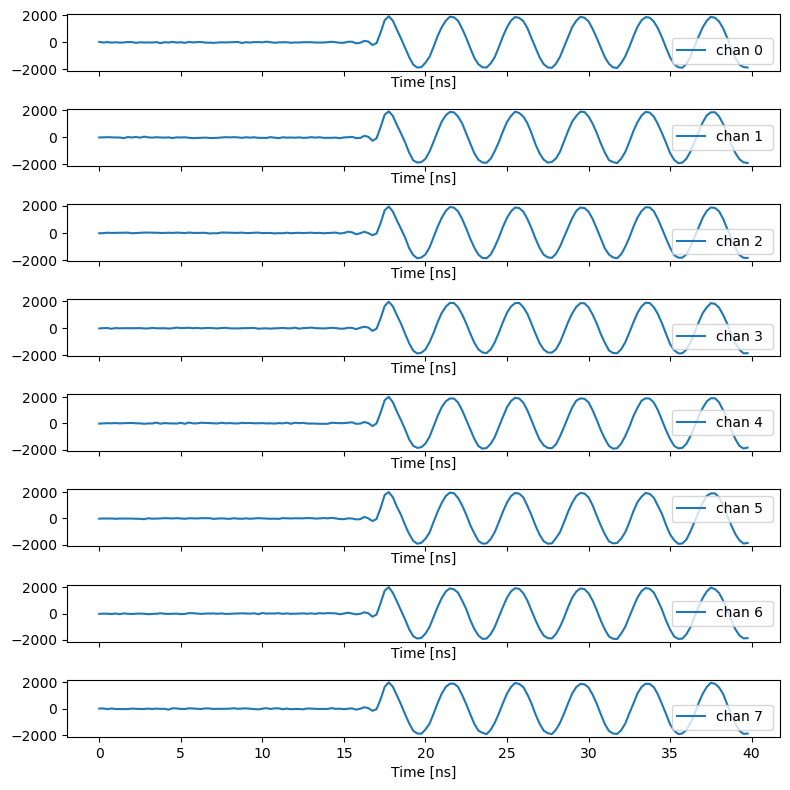

In [10]:
darray_i, darray_q = ol.capture_adc_iq_buf()
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

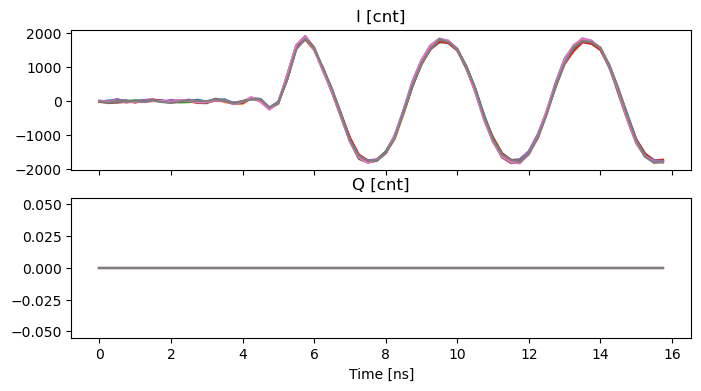

In [11]:
ol.capture_adc_iq_buf(darray_i, darray_q);
carray = darray_i + 1j * darray_q
plot_complex_wfm_stack(carray[:, start-32:start+32], fs=fs)

### Verify Alignment Stability

In [12]:
n_samples = 1024
for i in range(3):
    ol.capture_adc_iq_buf(darray_i, darray_q);
    x = darray_i[0, start:start+n_samples].astype(np.float32)  # adc0 Q
    y = darray_i[3, start:start+n_samples].astype(np.float32)  # adc3 Q
    x_corr = np.correlate(x, y, mode='full')
    lags = np.arange(-n_samples+1, n_samples)
    delay = lags[np.argmax(x_corr)]
    print(f'Iteration {i} : Cross-correlation delay = {delay} samples')
    assert delay == 0, 'Cross-correlation delay is not zero'

Iteration 0 : Cross-correlation delay = 0 samples
Iteration 1 : Cross-correlation delay = 0 samples
Iteration 2 : Cross-correlation delay = 0 samples


### Set DAC baseband waveform as DC, reset mixer

In [55]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)
ol.write_dac_iq_buf(dac_i, dac_q)

### Change DAC mixer setting with NCO to 125 MHz

In [14]:
ol.set_dac_mixer(125)

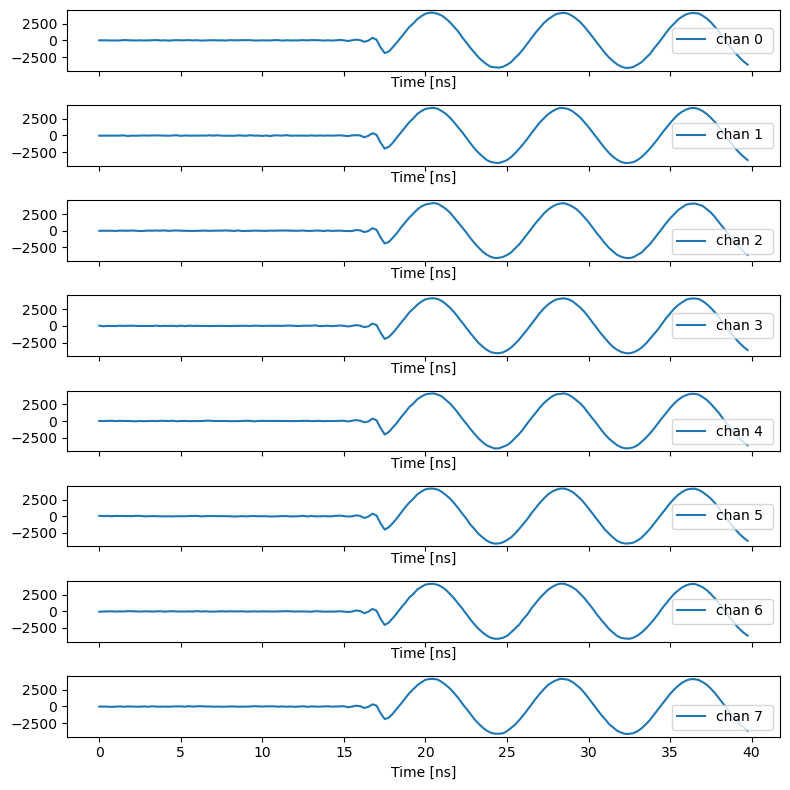

In [15]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80], fs=fs)

###  Change DAC mixer setting with NCO to 500 MHz

In [16]:
ol.set_dac_mixer(500)
ol.set_adc_mixer(0)

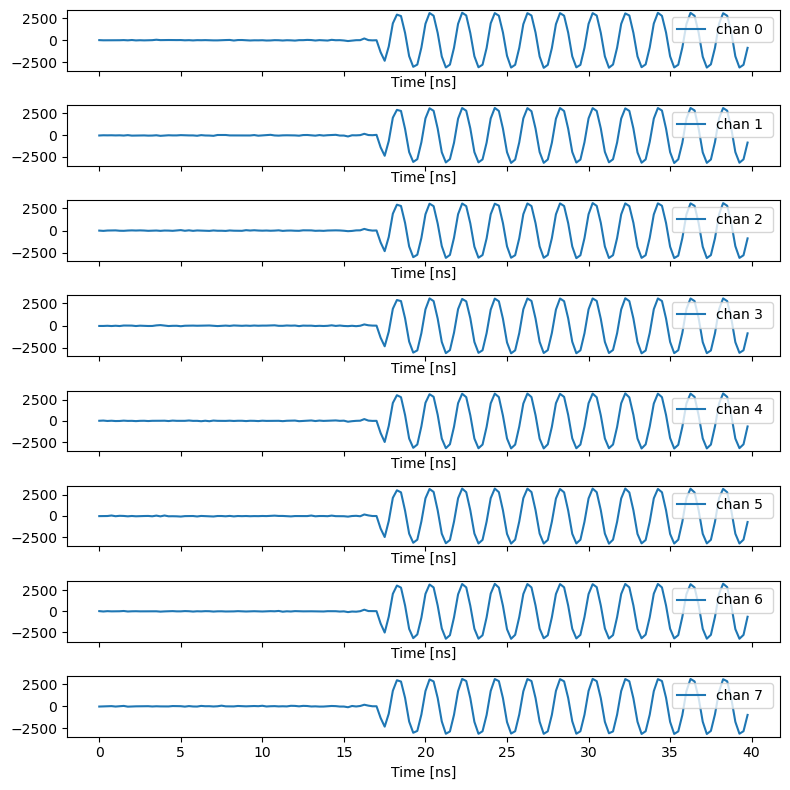

In [17]:
ol.capture_adc_iq_buf(darray_i, darray_q);
plot_adc_wfm(darray_i[:, start-80:start+80])

###  Change both DAC/ADC mixer setting, check base-band (DSP) waveforms after loopback

In [21]:
def get_dsp_waveform(ol=ol):
    """
    Get the DSP waveform from the ADC buffer.
    Average ADC data by 2 samples, as the same to the LLRF DSP,
    equivalent to a low pass filter to get base band signal.
    """
    darray_i, darray_q = ol.capture_adc_iq_buf()
    cdata = darray_i + 1j*darray_q
    return cdata.reshape(8, -1, 16).mean(axis=2)

In [48]:
ol.rf_control.register_map.dac_enable.pulse_enable=1
ol.rf_control.register_map.pulse_length=1000

In [38]:
ol.set_dac_mixer(125)
ol.set_adc_mixer(-125)

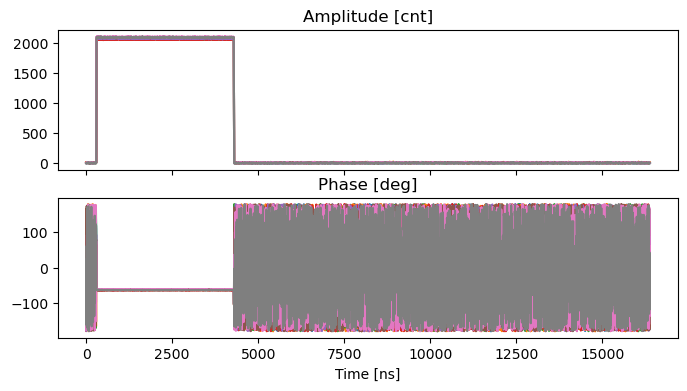

In [29]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp, fs=fs/16, mode='ap')

In [39]:
ol.set_dac_mixer(500)
ol.set_adc_mixer(-500)

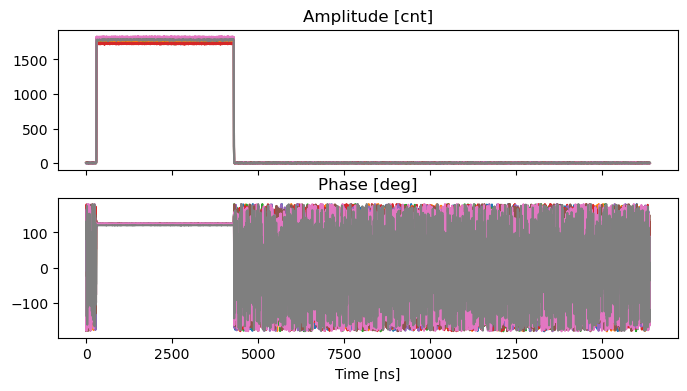

In [31]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp, fs=fs/16, mode='ap')

In [56]:
ol.set_dac_mixer(-3000, nyquist=2)
ol.set_adc_mixer(3000, nyquist=2)

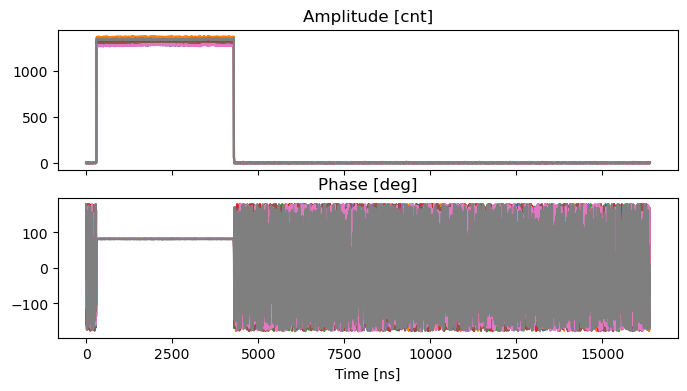

In [33]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp, fs=fs/16, mode='ap')

In [43]:
ol.dac_blocks[0,0].IncSincFIR=2

In [ ]:
v = getattr(ol.rf_control.register_map, 'pulse_length')


Register(value=2680)

In [61]:
ol.rf_control._registers

{'trig_sel': {'address_offset': 0,
  'access': 'read-write',
  'description': 'Trigger select, 0: internal, 1: EVR, 2: external',
  'size': 32},
 'trig_period': {'address_offset': 4,
  'access': 'read-write',
  'description': 'Trigger period',
  'size': 32},
 'trig_delay': {'address_offset': 8,
  'access': 'read-write',
  'description': 'Trigger delay',
  'size': 32},
 'trig_divide': {'address_offset': 12,
  'access': 'read-write',
  'description': 'Trigger divide',
  'size': 32},
 'pulse_length': {'address_offset': 16,
  'access': 'read-write',
  'description': 'Pulse length',
  'size': 32},
 'dac_enable': {'address_offset': 20,
  'access': 'read-write',
  'description': 'Pulse length',
  'size': 32,
  'fields': {'dac_enable': {'bit_offset': 0,
    'bit_width': 1,
    'access': 'read-write',
    'description': 'DAC enable'},
   'pulse_enable': {'bit_offset': 1,
    'bit_width': 1,
    'access': 'read-write',
    'description': 'Pulse enable'}}},
 'amp_loop_enable': {'address_offset': 